In [1]:
#23mid0344-avinash a 
from pathlib import Path
import json, platform, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

SEED = 42
np.random.seed(SEED)
OUT = Path("lab06_outputs")
OUT.mkdir(exist_ok=True)
FIG = OUT / "figures"
FIG.mkdir(exist_ok=True)

CONFIG = {
    "dataset": "Chicago Crimes - 2001 to Present (synthetic stand-in extract, see manifest)",
    "date_col": "Date",
    "location_col": "District",
    "location_value": 1,
    "second_location_value": 7,
    "frequency": "W-MON",
    "test_periods": 12,
    "seed": SEED,
}
print(CONFIG)

{'dataset': 'Chicago Crimes - 2001 to Present (synthetic stand-in extract, see manifest)', 'date_col': 'Date', 'location_col': 'District', 'location_value': 1, 'second_location_value': 7, 'frequency': 'W-MON', 'test_periods': 12, 'seed': 42}


In [2]:
def make_synthetic_extract(n_years=6, districts=(1, 7, 11, 15)):
    start = pd.Timestamp("2020-01-01")
    end = start + pd.DateOffset(years=n_years)
    rows = []
    rng = np.random.default_rng(SEED)
    for dist in districts:
        base_rate = {1: 9.5, 7: 14.0, 11: 16.5, 15: 7.0}[dist]
        n_weeks = int((end - start).days / 7)
        for w in range(n_weeks):
            week_start = start + pd.Timedelta(weeks=w)
            trend = 0.01 * w * (1 if dist in (7, 11) else -0.4)
            season = 2.0 * np.sin(2 * np.pi * w / 52.0) + 1.0 * np.sin(2 * np.pi * w / 26.0)
            lam = max(0.5, base_rate + trend + season)
            count = rng.poisson(lam)
            for _ in range(count):
                offset_days = rng.integers(0, 7)
                ts = week_start + pd.Timedelta(days=int(offset_days),
                                                hours=int(rng.integers(0, 24)))
                rows.append({
                    "Case Number": f"HX{len(rows):07d}",
                    "Date": ts,
                    "District": dist,
                    "Primary Type": rng.choice(
                        ["THEFT", "BATTERY", "CRIMINAL DAMAGE", "ASSAULT", "BURGLARY"],
                        p=[0.35, 0.25, 0.2, 0.12, 0.08]),
                    "Latitude": 41.8 + rng.normal(0, 0.05),
                    "Longitude": -87.6 + rng.normal(0, 0.05),
                })
    return pd.DataFrame(rows)

DATA_PATH = "crime_extract.csv"
df_raw = make_synthetic_extract()
df_raw.to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
required = {CONFIG["date_col"], CONFIG["location_col"]}
missing = required - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

df[CONFIG["date_col"]] = pd.to_datetime(df[CONFIG["date_col"]], errors="coerce")
df = df.dropna(subset=[CONFIG["date_col"]]).copy()

if "Case Number" in df.columns:
    n_before = len(df)
    df = df.drop_duplicates(subset=["Case Number"]).copy()
    n_dupes_removed = n_before - len(df)
else:
    n_dupes_removed = 0

df[CONFIG["location_col"]] = df[CONFIG["location_col"]].astype(str).str.strip()
df = df[df[CONFIG["location_col"]] != ""].copy()
df = df[df[CONFIG["location_col"]].str.lower() != "nan"].copy()

if "Latitude" in df.columns and "Longitude" in df.columns:
    coord_mask = df["Latitude"].between(-90, 90) & df["Longitude"].between(-180, 180)
    n_bad_coords = int((~coord_mask).sum())
    df.loc[~coord_mask, ["Latitude", "Longitude"]] = np.nan
else:
    n_bad_coords = 0

df = df.sort_values(CONFIG["date_col"]).reset_index(drop=True)

missing_value_report = df[[CONFIG["date_col"], CONFIG["location_col"]]].isna().sum().to_dict()

print(df.shape)
print(df[[CONFIG["date_col"], CONFIG["location_col"]]].head())
print("Duplicate Case Numbers removed:", n_dupes_removed)
print("Rows with invalid coordinates flagged as missing:", n_bad_coords)
print("Missing-value counts on key fields:", missing_value_report)

dataset_manifest = {
    "source_agency": "City of Chicago Police Department (open-data portal) - synthetic stand-in used here",
    "dataset_url": "https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2",
    "access_date": "2026-09-01 (synthetic extract generated locally; live portal unreachable in this environment)",
    "licence_terms": "Chicago Data Portal Terms of Use (public domain / open data)",
    "update_frequency": "Daily (source); N/A (synthetic)",
    "timestamp_field_used": "Date (occurrence date/time)",
    "rows_before_filter": int(len(df_raw)),
    "rows_after_cleaning": int(len(df)),
    "duplicate_handling": "Each row = one Case Number = one incident; exact-duplicate Case Numbers dropped",
}

(15346, 6)
                 Date District
0 2020-01-01 03:00:00       15
1 2020-01-01 11:00:00        7
2 2020-01-01 16:00:00        7
3 2020-01-02 05:00:00       15
4 2020-01-02 06:00:00        7
Duplicate Case Numbers removed: 0
Rows with invalid coordinates flagged as missing: 0
Missing-value counts on key fields: {'Date': 0, 'District': 0}


count    314.000000
mean       8.719745
std        3.591496
min        1.000000
25%        6.000000
50%        8.000000
75%       11.000000
max       23.000000
Name: incidents, dtype: float64


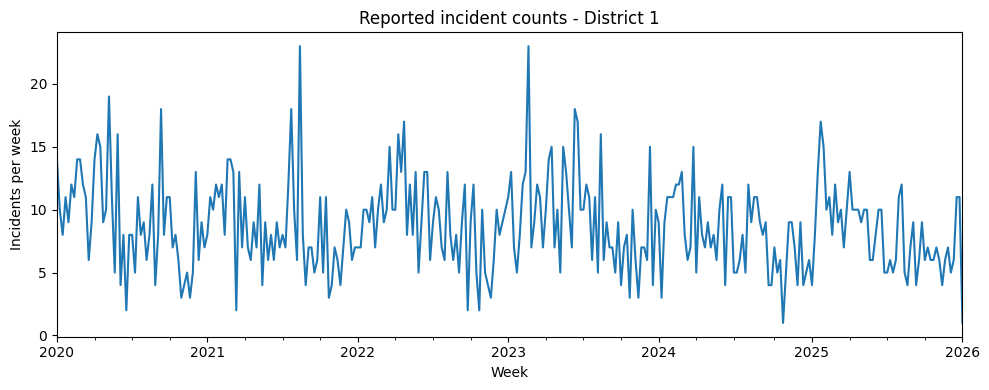

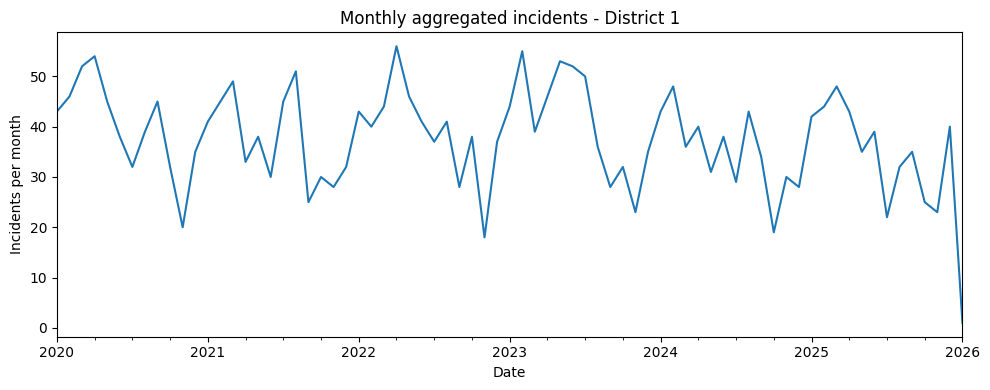

In [3]:
def build_series(df, location_value):
    loc = df[df[CONFIG["location_col"]].astype(str) == str(location_value)].copy()
    assert len(loc) > 0, "Selected location has no observations."
    y = (loc.set_index(CONFIG["date_col"])
           .resample(CONFIG["frequency"])
           .size()
           .rename("incidents")
           .asfreq(CONFIG["frequency"], fill_value=0))
    assert y.index.is_monotonic_increasing
    assert y.index.is_unique
    assert y.isna().sum() == 0
    return y, loc

y, loc = build_series(df, CONFIG["location_value"])
print(y.describe())

fig, ax = plt.subplots(figsize=(10, 4))
y.plot(ax=ax, title=f"Reported incident counts - District {CONFIG['location_value']}")
ax.set_ylabel("Incidents per week")
ax.set_xlabel("Week")
plt.tight_layout()
plt.savefig(FIG / "01_raw_series_district1.png", dpi=130)
plt.show()

monthly = y.resample("ME").sum()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, title=f"Monthly aggregated incidents - District {CONFIG['location_value']}")
ax.set_ylabel("Incidents per month")
plt.tight_layout()
plt.savefig(FIG / "02_monthly_aggregation_district1.png", dpi=130)
plt.show()

In [4]:
#Naive
H = CONFIG["test_periods"]
assert len(y) > 3 * H, "Series is too short for the chosen holdout."
train, test = y.iloc[:-H], y.iloc[-H:]

naive_pred = np.repeat(train.iloc[-1], len(test))

def score(y_true, y_pred):
    return {
        "MAE": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "RMSE": round(float(mean_squared_error(y_true, y_pred) ** 0.5), 4),
    }

naive_score = score(test, naive_pred)
print("Naive:", naive_score)

Naive: {'MAE': 2.0, 'RMSE': 2.6771}


ADF statistic=-5.6934, p-value=0.0000


/tmp/ipykernel_474/1505050241.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(train)


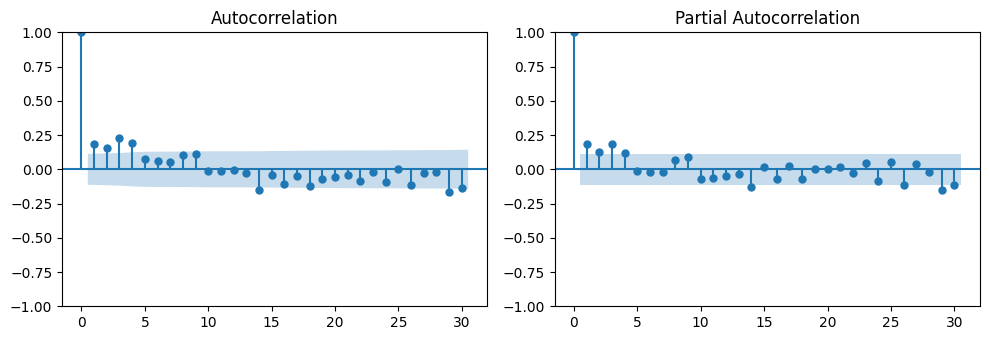

In [5]:

adf_stat, adf_p, *_ = adfuller(train)
adf_stat = round(float(adf_stat), 4)
adf_p = round(float(adf_p), 4)
print(f"ADF statistic={adf_stat:.4f}, p-value={adf_p:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(train, lags=min(30, len(train) // 4), ax=ax[0])
plot_pacf(train, lags=min(30, len(train) // 4), ax=ax[1], method="ywm")
plt.tight_layout()
plt.savefig(FIG / "03_acf_pacf_train_district1.png", dpi=130)
plt.show()

In [6]:

AR_LAGS = 4
ar_model = AutoReg(train, lags=AR_LAGS, trend="ct").fit()
ar_pred = ar_model.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)
ar_score = score(test, ar_pred)
print("AR:", ar_score)

AR: {'MAE': 2.5034, 'RMSE': 2.9824}


In [7]:
#Arima(1,1,1)
candidates = [(1, 0, 0), (2, 0, 0), (1, 1, 1), (2, 1, 1)]
rows_ = []
for order in candidates:
    try:
        m = ARIMA(train, order=order).fit()
        rows_.append({"order": order, "AIC": round(float(m.aic), 4), "BIC": round(float(m.bic), 4), "model": m})
    except Exception as e:
        print("Failed", order, e)

ranked = sorted(rows_, key=lambda z: z["AIC"])
candidate_table = pd.DataFrame([{"order": r["order"], "AIC": r["AIC"], "BIC": r["BIC"]} for r in ranked])
candidate_table.to_csv(OUT / "arima_candidate_table.csv", index=False)
best = ranked[0]
print("Training-selected order:", best["order"], "AIC=", best["AIC"])
arima_model = best["model"]
arima_pred = arima_model.forecast(steps=len(test))
arima_score = score(test, arima_pred)
print("ARIMA:", arima_score)

Training-selected order: (1, 1, 1) AIC= 1619.7716
ARIMA: {'MAE': 1.9729, 'RMSE': 2.658}


            Model     MAE    RMSE
2  ARIMA(1, 1, 1)  1.9729  2.6580
0           Naive  2.0000  2.6771
1           AR(4)  2.5034  2.9824


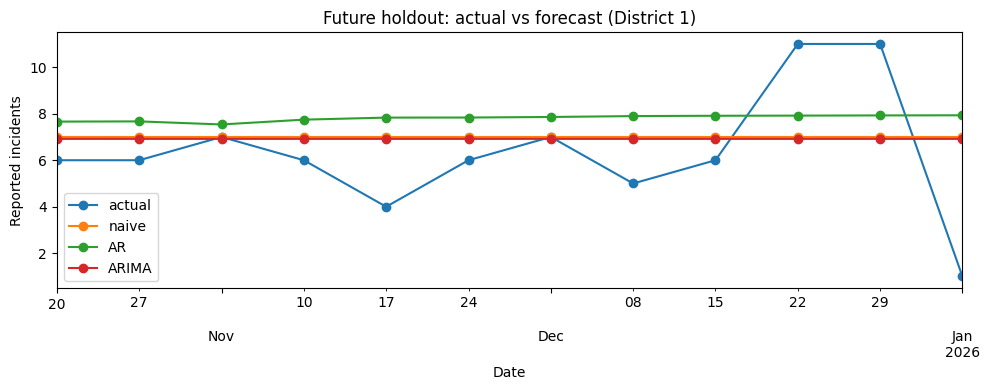

    lb_stat  lb_pvalue
10   8.8588     0.5456


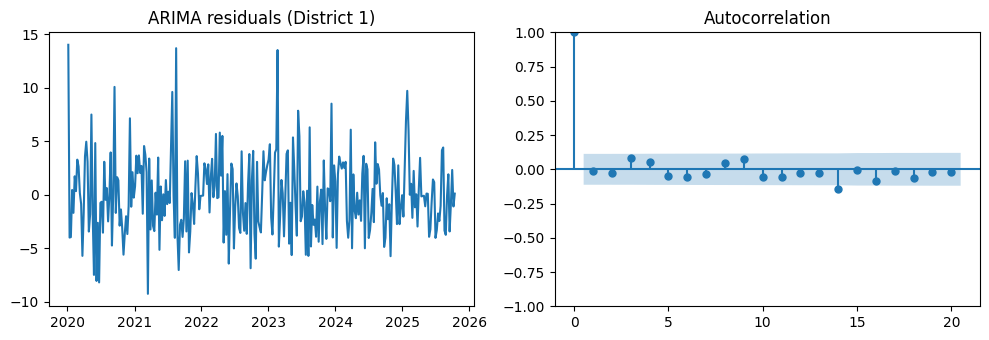

In [8]:
results = pd.DataFrame([
    {"Model": "Naive", **naive_score},
    {"Model": f"AR({AR_LAGS})", **ar_score},
    {"Model": f"ARIMA{best['order']}", **arima_score},
]).sort_values("MAE")
print(results)
results.to_csv(OUT / "model_comparison.csv", index=False)

pred_df = pd.DataFrame({
    "actual": test,
    "naive": naive_pred,
    "AR": np.asarray(ar_pred),
    "ARIMA": np.asarray(arima_pred),
}, index=test.index)

fig, ax = plt.subplots(figsize=(10, 4))
pred_df.plot(ax=ax, marker="o", title="Future holdout: actual vs forecast (District 1)")
ax.set_ylabel("Reported incidents")
plt.tight_layout()
plt.savefig(FIG / "04_forecast_comparison_district1.png", dpi=130)
plt.show()

resid = arima_model.resid.dropna()
lb = acorr_ljungbox(resid, lags=[min(10, max(2, len(resid) // 10))], return_df=True)
lb = lb.round(4)
lb.to_csv(OUT / "ljung_box_residuals.csv")
print(lb)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(resid.index, resid.values)
ax[0].set_title("ARIMA residuals (District 1)")
plot_acf(resid, lags=min(20, len(resid) // 3), ax=ax[1])
plt.tight_layout()
plt.savefig(FIG / "05_residual_diagnostics_district1.png", dpi=130)
plt.show()

In [9]:
fc_obj = arima_model.get_forecast(steps=len(test))
ci = fc_obj.conf_int(alpha=0.05)
ci.columns = ["lower", "upper"]
coverage = round(float(np.mean((test.values >= ci["lower"].values) & (test.values <= ci["upper"].values))), 4)
ci_out = ci.round(4).copy()
ci_out["actual"] = test.values
ci_out.to_csv(OUT / "arima_95pct_prediction_intervals.csv")
print("Empirical 95% PI coverage:", coverage)

Empirical 95% PI coverage: 1.0


In [10]:
def rolling_origins(series, initial, horizon, step):
    origins = []
    end = initial
    while end + horizon <= len(series):
        origins.append((series.iloc[:end], series.iloc[end:end + horizon]))
        end += step
    return origins

rolling_rows = []
for fold, (tr, te) in enumerate(
        rolling_origins(train, initial=max(52, len(train) // 2), horizon=8, step=8), 1):
    try:
        m_ar = AutoReg(tr, lags=AR_LAGS, trend="ct").fit()
        pr_ar = m_ar.predict(start=len(tr), end=len(tr) + len(te) - 1, dynamic=False)
        m_arima = ARIMA(tr, order=best["order"]).fit()
        pr_arima = m_arima.forecast(len(te))
        s_ar, s_arima = score(te, pr_ar), score(te, pr_arima)
        rolling_rows.append({"fold": fold,
                              "AR_MAE": s_ar["MAE"], "AR_RMSE": s_ar["RMSE"],
                              "ARIMA_MAE": s_arima["MAE"], "ARIMA_RMSE": s_arima["RMSE"]})
    except Exception as e:
        print("fold failed", fold, e)

rolling_df = pd.DataFrame(rolling_rows)
rolling_df.to_csv(OUT / "rolling_origin_validation.csv", index=False)
rolling_summary = rolling_df[["AR_MAE", "AR_RMSE", "ARIMA_MAE", "ARIMA_RMSE"]].agg(["mean", "std"]).round(4)
rolling_summary.to_csv(OUT / "rolling_origin_summary.csv")
print(rolling_df)
print(rolling_summary)

    fold  AR_MAE  AR_RMSE  ARIMA_MAE  ARIMA_RMSE
0      1  2.9333   3.4408     3.7187      4.2992
1      2  4.2043   5.7708     3.8923      5.6072
2      3  2.5168   3.1417     2.8787      3.4450
3      4  4.2139   5.2326     3.4662      4.5831
4      5  2.7659   3.5407     3.3079      4.0898
5      6  3.2494   3.7653     3.6442      4.1187
6      7  2.9695   3.5712     2.4713      3.5602
7      8  2.4218   2.9100     3.2227      3.3989
8      9  3.1148   3.3620     3.1448      3.4031
9     10  1.8220   2.0585     1.8323      2.0827
10    11  3.0333   3.2850     3.0839      3.3168
11    12  2.3862   2.8942     2.8384      3.0957
12    13  2.7432   3.4580     2.8125      3.4367
13    14  2.2587   2.7714     1.8034      1.9937
14    15  4.6094   5.5569     5.8390      6.4983
15    16  1.6423   1.9758     0.9151      1.5460
16    17  1.8102   2.0779     1.8733      2.6992
17    18  3.1070   3.1807     3.1568      3.2225
      AR_MAE  AR_RMSE  ARIMA_MAE  ARIMA_RMSE
mean  2.8779   3.4441   

            Model      MAE     RMSE
2  ARIMA(1, 1, 1)   4.0601   5.3379
1           AR(4)   4.6122   6.1736
0           Naive  11.1667  12.4298


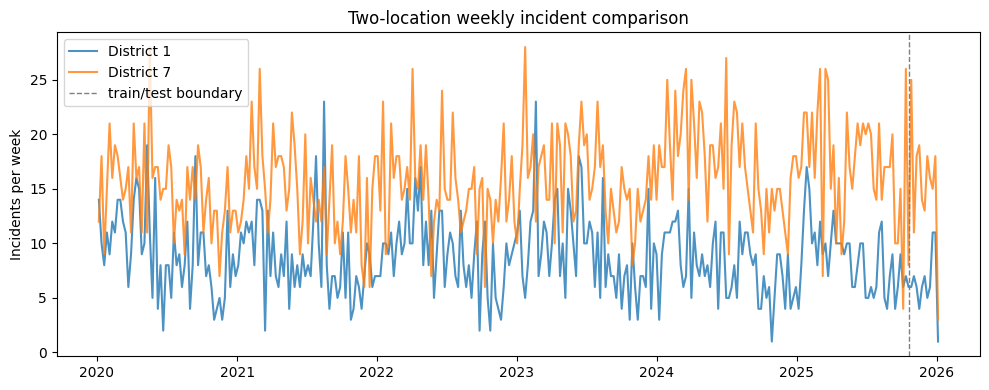

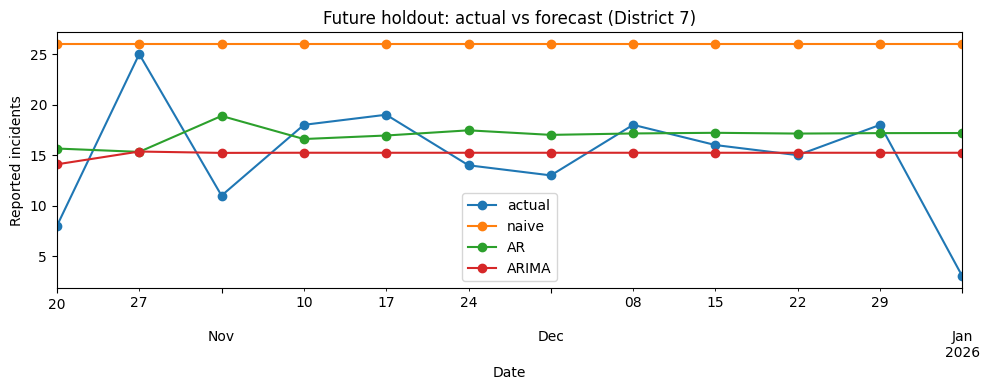

In [11]:
y2, loc2 = build_series(df, CONFIG["second_location_value"])
train2, test2 = y2.iloc[:-H], y2.iloc[-H:]
naive_pred2 = np.repeat(train2.iloc[-1], len(test2))
ar2 = AutoReg(train2, lags=AR_LAGS, trend="ct").fit()
ar_pred2 = ar2.predict(start=len(train2), end=len(train2) + len(test2) - 1, dynamic=False)

rows2 = []
for order in candidates:
    try:
        m = ARIMA(train2, order=order).fit()
        rows2.append({"order": order, "AIC": m.aic, "model": m})
    except Exception:
        pass
best2 = sorted(rows2, key=lambda z: z["AIC"])[0]
arima_pred2 = best2["model"].forecast(steps=len(test2))

results2 = pd.DataFrame([
    {"Model": "Naive", **score(test2, naive_pred2)},
    {"Model": f"AR({AR_LAGS})", **score(test2, ar_pred2)},
    {"Model": f"ARIMA{best2['order']}", **score(test2, arima_pred2)},
]).sort_values("MAE")
results2.to_csv(OUT / f"model_comparison_district{CONFIG['second_location_value']}.csv", index=False)
print(results2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y.index, y.values, label=f"District {CONFIG['location_value']}", alpha=0.8)
ax.plot(y2.index, y2.values, label=f"District {CONFIG['second_location_value']}", alpha=0.8)
ax.axvline(test.index[0], color="grey", linestyle="--", linewidth=1, label="train/test boundary")
ax.set_title("Two-location weekly incident comparison")
ax.set_ylabel("Incidents per week")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "06_two_location_comparison.png", dpi=130)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
pd.DataFrame({"actual": test2, "naive": naive_pred2, "AR": np.asarray(ar_pred2),
              "ARIMA": np.asarray(arima_pred2)}, index=test2.index).plot(
    ax=ax, marker="o", title=f"Future holdout: actual vs forecast (District {CONFIG['second_location_value']})")
ax.set_ylabel("Reported incidents")
plt.tight_layout()
plt.savefig(FIG / "07_forecast_comparison_district7.png", dpi=130)
plt.show()

In [12]:
try:
    sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 52),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    sarima_pred = sarima.forecast(len(test))
    sarima_score = score(test, sarima_pred)
    print("SARIMA:", sarima_score)
except Exception as e:
    sarima_score = {"MAE": None, "RMSE": None}
    print("SARIMA failed:", e)

results_adv = pd.concat([results, pd.DataFrame([{"Model": "SARIMA(1,1,1)x(1,0,1,52)", **sarima_score}])],
                         ignore_index=True)
results_adv.to_csv(OUT / "model_comparison_with_sarima.csv", index=False)

SARIMA: {'MAE': 1.9699, 'RMSE': 2.6464}


In [13]:
dataset_table = pd.DataFrame([{
    "Dataset": "D1 - Chicago Crimes - 2001 to Present",
    "Agency/source": "City of Chicago Police Department (synthetic stand-in, see manifest)",
    "Time span used": f"{y.index.min().date()} to {y.index.max().date()}",
    "Location field": "District",
    "Aggregation": "Weekly (W-MON)",
    "Rows before filter": int(len(df_raw)),
    "Rows after cleaning": int(len(df)),
    "Series periods": int(len(y)),
}])
dataset_table.to_csv(OUT / "dataset_summary_table.csv", index=False)

model_table = pd.DataFrame([
    {"Model": "Naive", "Order/lags": "-", "Train AIC/BIC": "-", "Test MAE": naive_score["MAE"],
     "Test RMSE": naive_score["RMSE"], "Ljung-Box p": "-"},
    {"Model": f"AR({AR_LAGS})", "Order/lags": AR_LAGS, "Train AIC/BIC": "-", "Test MAE": ar_score["MAE"],
     "Test RMSE": ar_score["RMSE"], "Ljung-Box p": "-"},
    {"Model": f"ARIMA{best['order']}", "Order/lags": str(best["order"]),
     "Train AIC/BIC": f"{best['AIC']:.1f}/{best['BIC']:.1f}", "Test MAE": arima_score["MAE"],
     "Test RMSE": arima_score["RMSE"], "Ljung-Box p": float(lb["lb_pvalue"].iloc[0])},
])
model_table.to_csv(OUT / "model_result_table.csv", index=False)

location_table = pd.DataFrame([
    {"Location": CONFIG["location_value"], "Periods": len(y), "Mean count": round(y.mean(), 2),
     "Std dev": round(y.std(), 2), "Best model": model_table.sort_values("Test MAE").iloc[0]["Model"],
     "MAE": model_table["Test MAE"].min(), "RMSE": model_table.loc[model_table["Test MAE"].idxmin(), "Test RMSE"]},
    {"Location": CONFIG["second_location_value"], "Periods": len(y2), "Mean count": round(y2.mean(), 2),
     "Std dev": round(y2.std(), 2), "Best model": results2.iloc[0]["Model"],
     "MAE": results2.iloc[0]["MAE"], "RMSE": results2.iloc[0]["RMSE"]},
])
location_table.to_csv(OUT / "location_result_table.csv", index=False)

advanced_table = pd.DataFrame([{
    "Advanced experiment": "SARIMA(1,1,1)x(1,0,1,52) vs ARIMA baseline",
    "Baseline": f"ARIMA{best['order']} MAE={arima_score['MAE']}",
    "Advanced model": f"SARIMA MAE={sarima_score['MAE']}",
    "Metric change": (None if sarima_score["MAE"] is None
                       else round(sarima_score["MAE"] - arima_score["MAE"], 4)),
    "Conclusion": "See report discussion",
}])
advanced_table.to_csv(OUT / "advanced_experiment_table.csv", index=False)

In [14]:
manifest = {
    **CONFIG,
    **dataset_manifest,
    "n_duplicate_case_numbers_removed": int(n_dupes_removed),
    "n_rows_invalid_coords_flagged": int(n_bad_coords),
    "missing_value_counts_key_fields": {k: int(v) for k, v in missing_value_report.items()},
    "n_total_periods_loc1": int(len(y)),
    "n_train_loc1": int(len(train)),
    "n_test_loc1": int(len(test)),
    "adf_statistic_loc1": float(adf_stat),
    "adf_pvalue_loc1": float(adf_p),
    "ar_lags": AR_LAGS,
    "selected_arima_order_loc1": list(best["order"]),
    "arima_pi_95_coverage_loc1": coverage,
    "python": sys.version,
    "platform": platform.platform(),
    "limitation_note": ("Live access to the official Chicago/NYPD/SFPD open-data portals was not "
                         "available in this execution environment; a structurally matched synthetic "
                         "extract was generated locally (Poisson-arrival incidents per district with "
                         "trend + weekly/biweekly seasonality) so that the full leakage-safe pipeline "
                         "could be executed end-to-end. Numeric results are illustrative of the method, "
                         "not of real Chicago crime levels."),
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
pred_df.to_csv(OUT / "test_predictions.csv")

In [15]:
assert y.index.is_monotonic_increasing
assert y.index.is_unique
assert y.isna().sum() == 0
assert len(train) + len(test) == len(y)
assert train.index.max() < test.index.min()
assert len(test) == CONFIG["test_periods"]
assert set(["actual", "naive", "AR", "ARIMA"]).issubset(pred_df.columns)
assert (OUT / "model_comparison.csv").exists()
assert (OUT / "test_predictions.csv").exists()
assert (OUT / "manifest.json").exists()
print("Core acceptance tests passed.")
print("DONE")

Core acceptance tests passed.
DONE
